In [23]:
import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from envs.register import register_envs
register_envs()

from learners import Qlearning, QuantileRegression
from explorers import EpsilonGreedy
from dist_run import *
from policy_util import *
from analysis import *

params = Params(
    model_name="Simple-v1",
    total_episodes=1_000_000,
    save_skip=100,
    n_runs=1,
    seed=123,
    
    lr_decay=2000,
    learning_rate=0.1,

    gamma=1.0,
    epsilon=1.0,
    huber_k=0.0,
    n_quantiles=256,
    
    action_size=None,
    state_size=None,
    map_size=None,
    
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.n_quantiles) + 0.5) / params.n_quantiles

env = gym.make(params.model_name)
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)

env.reset()
s_init = env.unwrapped.s

learner = QuantileRegression(params)
if isinstance(learner, Qlearning): params = params._replace(n_quantiles=1)
if params.learner_name is None:
    params = params._replace(learner_name=str(learner).split(".")[1].split(" ")[0])

In [114]:
# random_policy = np.ones((params.state_size, params.action_size))
# returns = MonteCarlo(env, random_policy, params, 4, rng, total_episodes=500_000)

In [24]:
learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables_run = run_env(env, learner, explorer, params, show_progress=False)

tables = tables_run.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]

Run 0/1 - Episodes: 100%|██████████| 1000000/1000000 [01:15<00:00, 13208.11it/s]


In [60]:
r_policy = np.ones((params.state_size, params.action_size))/params.action_size
returns = MonteCarlo(env, r_policy, params, s_init, rng, total_episodes=1_000_000)

100%|██████████| 1000000/1000000 [00:12<00:00, 79674.79it/s]


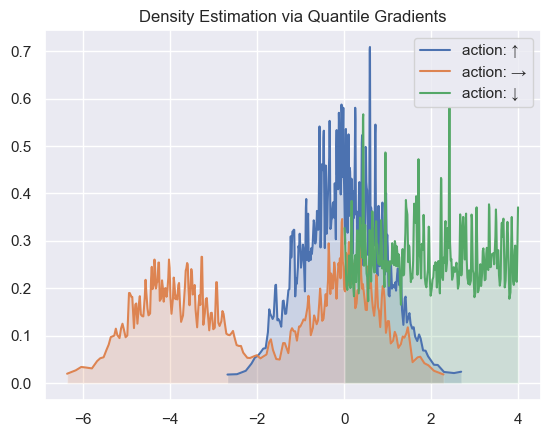

In [101]:
plot_grad(tables[-1,4], params)

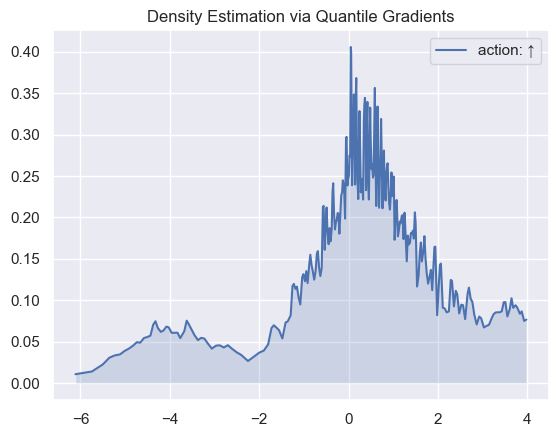

In [99]:
quant = tables[-1,4].reshape(-1)

# plot_kde(tables[-1,4], params, bandwidth=0.1)
# plot_returns(tau_returns, bandwidth=0.08)
tau_returns = np.quantile(returns, tau)
tau_quant = np.quantile(quant, tau)

plot_grad(tau_quant[None,:], params)
# plot_grad(tau_returns[None,:], params)
# plot_returns(tables[-1,4].reshape(-1), bandwidth=0.1)

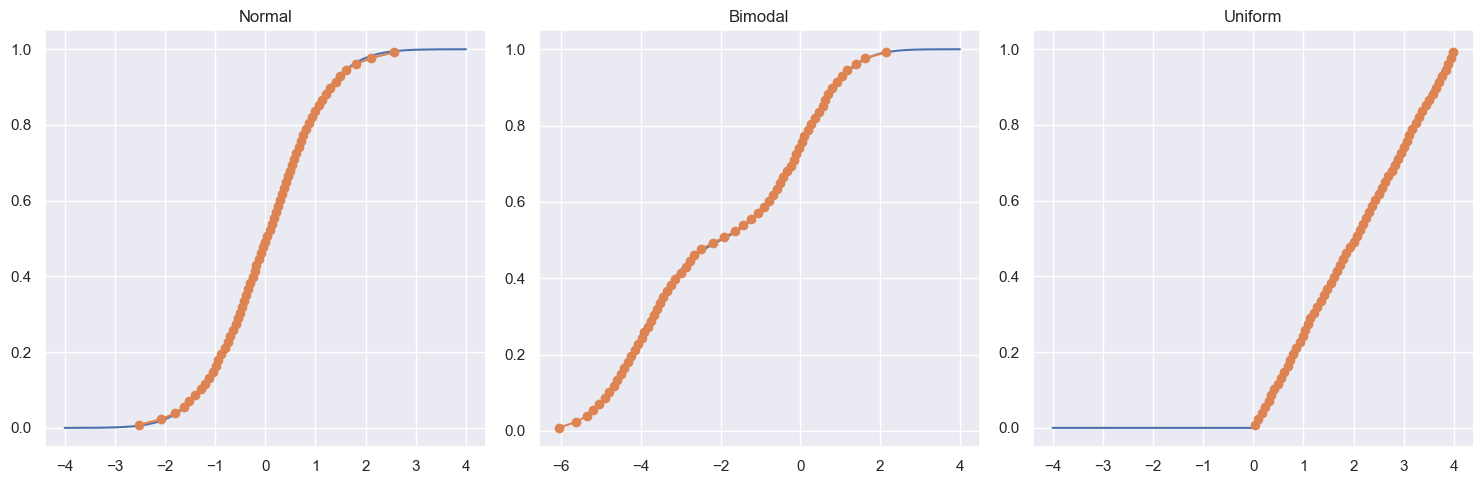

In [6]:
from matplotlib import pyplot as plt
import scipy.stats as stats
import numpy as np

normal = lambda x : stats.norm.cdf(x, 0, 1)
bimodal = lambda x : 0.5 * stats.norm.cdf(x, -4, 1) + 0.5 * stats.norm.cdf(x, 0, 1)
uniform = lambda x : np.where(x < 0, 0, np.where(x <= 4, 0.25 * x, 1))

quantiles = tables[-1, 4]
funcs = [normal, bimodal, uniform]
names = ["Normal", "Bimodal", "Uniform"]

plt.figure(figsize=(15,5))
for i in range(len(quantiles)):
    plt.subplot(1, 3, i+1)
    q = quantiles[i]
    x = np.linspace(-4, 4, 1000)
    plt.plot(x, funcs[i](x))
    plt.plot(q, tau, marker="o")
    plt.title(names[i])
plt.tight_layout()
plt.show()

In [102]:
def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))
N = 32
theta = np.ones(N)/N
lr = 1.0

In [103]:
this_theta = theta.copy()

for _ in range(10_000):
    pred_quantiles = this_theta
    target_quantiles = (np.random.normal(-4) if np.random.rand() < 0.5 else np.random.normal(0)) + np.zeros(N)
    u = target_quantiles[None, :] - pred_quantiles[:, None]
    rho = -np.abs(tau[:, None] - (u < 0).astype(float)) * du_huber(u, k=1.0)
    this_theta -= lr * rho.mean(1)

plt.figure(figsize=(5,5))
x = np.linspace(-6, 2, 1000)
plt.plot(x, bimodal(x))
plt.plot(this_theta, tau, marker="o")
plt.plot(theta, tau, marker="o")
plt.xlim(x.min(),x.max())
plt.tight_layout()
plt.show()

theta = this_theta
lr *= 0.5

ValueError: operands could not be broadcast together with shapes (256,1) (32,32) 

In [20]:
from tqdm import tqdm

env = gym.make(params.model_name)
total_rewards = []

for episode in tqdm(range(200_000)):
    state, _ = env.reset()
    done = False
    total_reward = 0
    discount = 1.0

    while not done:
        action = np.random.randint(0, params.action_size)
        next_state, reward, terminated, truncated, _ = env.step(action)

        total_reward += discount * reward
        discount *= params.gamma

        state = next_state
        done = terminated or truncated

    total_rewards.append(total_reward)
total_rewards.sort()
total_rewards = np.array(total_rewards)

100%|██████████| 200000/200000 [00:01<00:00, 177167.94it/s]


NameError: name 'total_rewards' is not defined

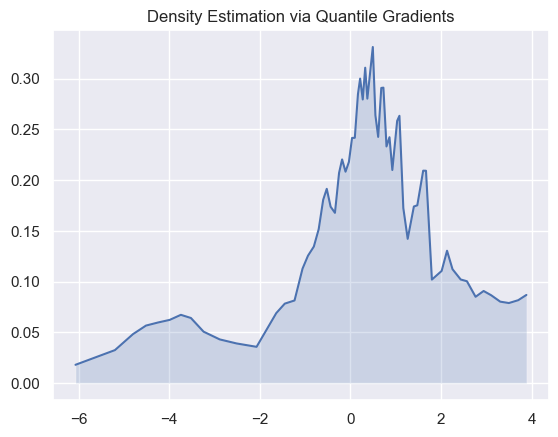

In [8]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

arrow_directions = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def plot_grad(quantiles, is_filled=True):
    r = quantiles.reshape(-1)
    r.sort()
    tau = (np.arange(len(r)) + 0.5) / len(r)
    plt.plot(r, np.gradient(tau, r))
    if is_filled:
        plt.fill_between(r, np.gradient(tau, r), alpha=0.2)
    plt.title("Density Estimation via Quantile Gradients")


r = quantiles.reshape(-1)
r.sort()
tau = (np.arange(len(r)) + 0.5) / len(r)
# plt.hist(r, bins=80);
plot_grad(r[::3][::1])
plot_grad(total_rewards[(tau*len(total_rewards)).round().astype(int)][::1])

# plt.plot(total_rewards[(tau*len(total_rewards)).round().astype(int)]);